Load Dataset (MNIST)

In [1]:
!pip install kaggle

In [2]:
kaggle = '/content/kaggle.json'

In [3]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 2.94GB/s]


In [5]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [6]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [7]:
len(data_0)

2236

Import Library Dasar

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

Preprocessing Data

In [21]:
data_path = '/content/dataset'
X = []
y = []

for label in range(10):
    folder_path = os.path.join(data_path, str(label))
    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (28, 28))

            X.append(image)
            y.append(label)
        except Exception as e:
            pass

X = np.array(X)
y = np.array(y)

print(f"Total data gambar: {len(X)}")

Total data gambar: 21555


Data Splitting dan Normalisasi

In [22]:
X = X.reshape(X.shape[0], 28*28)

X = X.astype('float32') / 255

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_enc = to_categorical(y_train, 10)
y_test_enc = to_categorical(y_test, 10)

print("Data training siap:", X_train.shape)

Data training siap: (17244, 784)


Membuat Model (MLP)

In [23]:
model = Sequential()

model.add(Dense(512, activation='relu', input_dim=784))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Kompilasi dan Training Model

In [25]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_enc,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1047 - loss: 2.4490 - val_accuracy: 0.1577 - val_loss: 2.2786
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1409 - loss: 2.2704 - val_accuracy: 0.2189 - val_loss: 2.1672
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1980 - loss: 2.1744 - val_accuracy: 0.2450 - val_loss: 2.0788
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2274 - loss: 2.1057 - val_accuracy: 0.3146 - val_loss: 1.9828
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2591 - loss: 2.0373 - val_accuracy: 0.3123 - val_loss: 1.9822
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2724 - loss: 2.0045 - val_accuracy: 0.3447 - val_loss: 1.8899
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2834 - loss: 1.9721 - val_accuracy: 0.3471 - val_loss: 1.9029
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2989 - loss: 1.9372 - val_accu

Evaluasi Model

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4420 - loss: 1.6963
Akurasi Data Test: 45.21%


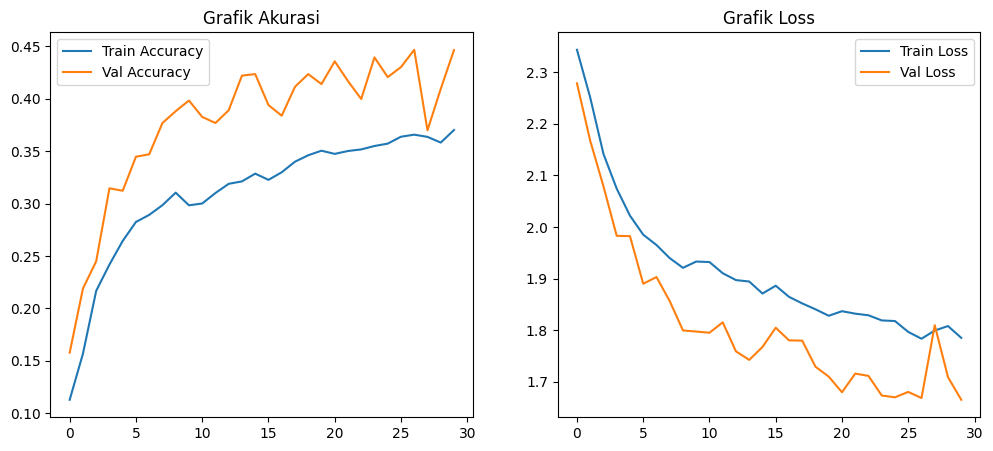

In [26]:
loss, accuracy = model.evaluate(X_test, y_test_enc)
print(f"Akurasi Data Test: {accuracy*100:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()